In [13]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [14]:
def mass_spring(z):
    p, q = z
    return p**2 + q**2

In [15]:
import torch
import numpy as np

p0 = torch.tensor([-0.0429839], requires_grad=True)
q0 = torch.tensor([0.44432778], requires_grad=True)
T = 200
dt = 0.1

In [16]:
from leapfrog_integrator import leapfrog

trajectories = leapfrog(p0, q0, mass_spring, dt, T, is_hamiltonian=True)


100%|██████████| 200/200 [00:00<00:00, 1383.86it/s]


In [17]:
trajectories.shape

torch.Size([200, 2])

In [18]:
traj = trajectories.detach().cpu()

traj = traj[:, :]        
p = traj[:, 0]
q = traj[:, 1]

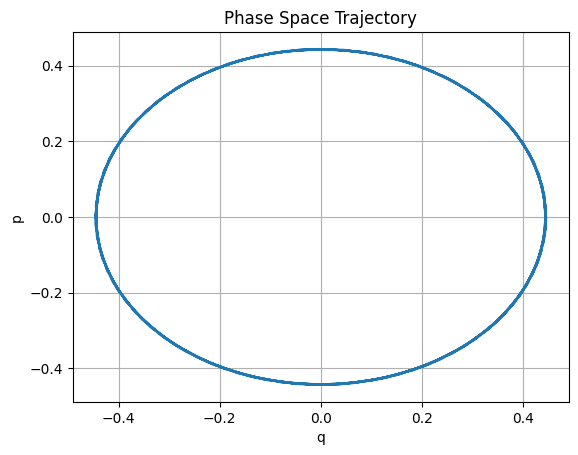

In [19]:
import matplotlib.pyplot as plt


plt.figure()
plt.plot(q, p)
plt.xlabel("q")
plt.ylabel("p")
plt.title("Phase Space Trajectory")
plt.grid(True)
plt.show()

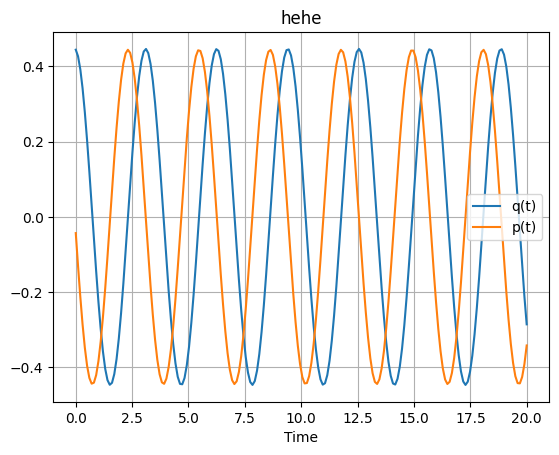

In [20]:
t_eval = np.linspace(0.0, T * dt, T)

plt.figure()
plt.plot(t_eval, q, label="q(t)")
plt.plot(t_eval, p, label="p(t)")
plt.xlabel("Time")
plt.legend()
plt.title("hehe")
plt.grid(True)
plt.show()